### Import libraries

In [69]:
import jax
import optax
from flax import nnx
import jax.numpy as jnp
from functools import partial
import matplotlib.pyplot as plt
from typing import Tuple, Callable
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

In [2]:
jax.devices()

[CudaDevice(id=0)]

### Preprocessing data

In [74]:
digits = load_digits()

# select only digits that are 1
images = digits.images[digits.target == 1]

# normalize the images
images = images / 16

# convert to jax arrays
images = jnp.asarray(images)

# reshape to number of images, width, height, channel for convolutional layers.
images = images.reshape(-1, 8, 8, 1)

train_img, images_test = train_test_split(images, test_size=0.10, random_state=42)
print(f"Training set size: {train_img.shape=}")
print(f"Test set size: {test_img.shape=}")

Training set size: train_img.shape=(163, 8, 8, 1)
Test set size: test_img.shape=(19, 8, 8, 1)


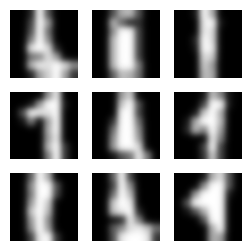

In [4]:
# Visualize sample images.
fig, axes = plt.subplots(3, 3, figsize=(3, 3))
for i, ax in enumerate(axes.flat):
    if i < len(train_img):
        ax.imshow(train_img[i, ..., 0], cmap='gray', interpolation='gaussian')
        ax.axis('off')
plt.show()

### Building the model

In [52]:
class UNet(nnx.Module):
    def __init__(self, in_channels: int, out_channels: int, features: int, time_emb_dim: int = 128, * , rngs: nnx.Rngs):
        self.features = features

        # time embedding layers for diffusion timestep conditioning
        self.time_mlp_1 = nnx.Linear(in_features = time_emb_dim, out_features = time_emb_dim, rngs = rngs)
        self.time_mlp_2 = nnx.Linear(in_features = time_emb_dim, out_features = time_emb_dim, rngs = rngs)

        # time projection layer for different scales
        self.time_proj_1 = nnx.Linear(in_features = time_emb_dim, out_features = features, rngs = rngs)
        self.time_proj_2 = nnx.Linear(in_features = time_emb_dim, out_features = features * 2, rngs = rngs)
        self.time_proj_3 = nnx.Linear(in_features = time_emb_dim, out_features = features * 4, rngs = rngs)
        self.time_proj_4 = nnx.Linear(in_features = time_emb_dim, out_features = features * 8, rngs = rngs)

        # encoder block
        self.down_conv_1 = self._residual_block(in_channels, features, rngs)
        self.down_conv_2 = self._residual_block(features, features * 2, rngs)
        self.down_conv_3 = self._residual_block(features * 2, features * 4, rngs)
        self.down_conv_4 = self._residual_block(features * 4, features * 8, rngs)

        # attention block
        self.attention_1 = self._attention_block(features * 4, rngs)
        self.attention_2 = self._attention_block(features * 8, rngs)

        # bridge connecting encoder and decoder
        self.bridge_down = self._residual_block(features * 8, features * 16, rngs)
        self.bridge_attention = self._attention_block(features * 16, rngs)
        self.bridge_up = self._residual_block(features * 16, features * 16, rngs)

        # decoder block
        self.up_conv_4 = self._residual_block(features * 24, features * 8, rngs)
        self.up_conv_3 = self._residual_block(features * 12, features * 4, rngs)
        self.up_conv_2 = self._residual_block(features * 6, features * 2, rngs)
        self.up_conv_1 = self._residual_block(features * 3, features, rngs)

        # output layer
        self.final_norm = nnx.LayerNorm(features, rngs = rngs)
        self.final_conv = nnx.Conv(in_features = features, out_features = out_channels, kernel_size = (3, 3), strides = (1, 1), padding = ((1, 1), (1, 1)), rngs = rngs)

    def _attention_block(self, channels: int, rngs: nnx.Rngs) -> Callable:
        w_q = nnx.Linear(in_features = channels, out_features = channels, rngs = rngs)
        w_k = nnx.Linear(in_features = channels, out_features = channels, rngs = rngs)
        w_v = nnx.Linear(in_features = channels, out_features = channels, rngs = rngs)

        def forward(x: jax.Array) -> jax.Array:
            B, H, W, C = x.shape
            scale = jnp.sqrt(C).astype(x.dtype)
            
            # q, k, v weights
            q = w_q(x)
            k = w_k(x)
            v = w_v(x)

            # reshape for attention computation
            q = q.reshape(B, H * W, C)
            k = k.reshape(B, H * W, C)
            v = v.reshape(B, H * W, C)

            # scaled dot product attention
            attention_map = jnp.einsum('bic, bjc -> bij', q, k) / scale
            attention_map = jax.nn.softmax(attention_map, axis = -1)

            # output tensor
            out = jnp.einsum('bij, bjc -> bic', attention_map, v)
            out = out.reshape(B, H, W, C)
            return x + out

        return forward

    def _residual_block(self, in_channels: int, out_channels: int, rngs: nnx.Rngs) -> Callable:
        conv_1 = nnx.Conv(in_features = in_channels, out_features = out_channels, kernel_size = (3, 3), strides = (1, 1), padding = ((1, 1), (1, 1)), rngs = rngs)
        norm_1 = nnx.LayerNorm(out_channels, rngs = rngs)

        conv_2 = nnx.Conv(in_features = out_channels, out_features = out_channels, kernel_size = (3, 3), strides = (1, 1), padding = ((1, 1), (1, 1)), rngs = rngs)
        norm_2 = nnx.LayerNorm(out_channels, rngs = rngs)

        shortcut = nnx.Conv(in_features = in_channels, out_features = out_channels, kernel_size = (1, 1), strides = (1, 1), rngs = rngs)

        def forward(x: jax.Array) -> jax.Array:
            identity = shortcut(x)

            x = conv_1(x)
            x = norm_1(x)
            x = nnx.gelu(x)

            x = conv_2(x)
            x = norm_2(x)
            x = nnx.gelu(x)
            return x + identity

        return forward
    
    def _pos_encoding(self, t: jax.Array, dim: int) -> jax.Array:
        half_dim = dim // 2
        emb = jnp.log(10000.0) / (half_dim - 1)
        emb = jnp.exp(jnp.arange(half_dim) * -emb)
        emb = t[:, None] * emb[None, :]
        emb = jnp.concatenate([jnp.sin(emb), jnp.cos(emb)], axis = 1)
        return emb

    def _downsample(self, x: jax.Array) -> jax.Array:
        return nnx.max_pool(x, window_shape=(2, 2), strides = (2, 2), padding="SAME")
    
    def _upsample(self, x: jax.Array, target_size: int) -> jax.Array:
        return jax.image.resize(x, (x.shape[0], target_size, target_size, x.shape[3]), method="nearest")

    def __call__(self, x: jax.Array, t: jax.Array) -> jax.Array:
        t_emb = self._pos_encoding(t, 128)
        t_emb = self.time_mlp_1(t_emb)
        t_emb = nnx.gelu(t_emb)
        t_emb = self.time_mlp_2(t_emb)
        
        t_emb_1 = self.time_proj_1(t_emb)[:, None, None, :]
        t_emb_2 = self.time_proj_2(t_emb)[:, None, None, :]
        t_emb_3 = self.time_proj_3(t_emb)[:, None, None, :]
        t_emb_4 = self.time_proj_4(t_emb)[:, None, None, :]

        # the encoder
        d1 = self.down_conv_1(x)
        t_emb_1 = jnp.broadcast_to(t_emb_1, d1.shape)
        d1 = d1 + t_emb_1

        d2 = self.down_conv_2(self._downsample(d1))
        t_emb_2 = jnp.broadcast_to(t_emb_2, d2.shape)
        d2 = d2 + t_emb_2

        d3 = self.down_conv_3(self._downsample(d2))
        d3 = self.attention_1(d3)
        t_emb_3 = jnp.broadcast_to(t_emb_3, d3.shape)
        d3 = d3 + t_emb_3

        d4 = self.down_conv_4(self._downsample(d3))
        d4 = self.attention_2(d4)
        t_emb_4 = jnp.broadcast_to(t_emb_4, d4.shape)
        d4 = d4 + t_emb_4

        # the bridge
        b = self._downsample(d4)
        b = self.bridge_down(b)
        b = self.bridge_attention(b)
        b = self.bridge_up(b)

        # the deocder 
        u4 = self.up_conv_4(jnp.concatenate([self._upsample(b, d4.shape[1]), d4], axis=-1))
        u3 = self.up_conv_3(jnp.concatenate([self._upsample(u4, d3.shape[1]), d3], axis=-1))
        u2 = self.up_conv_2(jnp.concatenate([self._upsample(u3, d2.shape[1]), d2], axis=-1))
        u1 = self.up_conv_1(jnp.concatenate([self._upsample(u2, d1.shape[1]), d1], axis=-1))

        # final layer
        x = self.final_norm(u1)
        x = nnx.gelu(x)
        return self.final_conv(x)


In [76]:
class DiffusionModel:
    def __init__(self, model: UNet, num_steps: int, beta_start: float, beta_end: float):
        self.model = model
        self.num_steps = num_steps

        # Noise schedule parameters
        self.beta = self._cosine_beta_scheduler(num_steps, beta_start, beta_end)
        self.alpha = 1 - self.beta
        self.alpha_cumulative = jnp.cumprod(self.alpha)

        self.sqrt_alpha_cumulative = jnp.sqrt(self.alpha_cumulative)
        self.sqrt_one_minus_alpha_cumulative = jnp.sqrt(1 - self.alpha_cumulative)
        self.sqrt_recip_alpha = jnp.sqrt(1 / self.alpha)

        self.posterior_variance = self.beta * (1 - self.alpha_cumulative) / (1 -  self.alpha_cumulative + 1e-7)
    
    def _cosine_beta_scheduler(self, num_steps: int, beta_start: float, beta_end: float) -> jax.Array:
        steps = jnp.linspace(0, num_steps, num_steps + 1)
        x = steps / num_steps
        alphas = jnp.cos(((x + 0.008) / 1.008) * jnp.pi * 0.5) ** 2
        alphas = alphas / alphas[0]
        betas = 1 - (alphas[1:] / alphas[:-1])
        betas = jnp.clip(betas, beta_start, beta_end)
        return jnp.concatenate([betas[0:1], betas])

    def forward(self, x: jax.Array, t: jax.Array, key: jax.Array) -> Tuple[jax.Array, jax.Array]:
        noise = jax.random.normal(key, x.shape)
        noise_x = (
            jnp.sqrt(self.alpha_cumulative[t])[:, None, None, None] * x +
            jnp.sqrt(self.alpha_cumulative[t])[:, None, None, None] * noise
        )
        return noise_x, noise

    def reverse(self, x: jax.Array, key: jax.Array) -> jax.Array:
        x_t = x
        for t in reversed(range(self.num_steps)):
            t_batch = jnp.array([t] * x.shape[0])
            predicted = self.model(x_t, t_batch)

            key, subkey = jax.random.split(key)
            noise = jax.random.normal(subkey, x_t.shape) if t > 0 else 0

            x_t = (1 / jnp.sqrt(self.alpha[t])) * (
                x_t - ((1 - self.alpha[t]) / jnp.sqrt(1 - self.alpha_cumulative[t])) * predicted
            ) + jnp.sqrt(self.beta[t]) * noise

        return x_t


In [77]:
def loss_fun(
    model: UNet,
    images: jax.Array,
    t: jax.Array,
    noise: jax.Array,
    sqrt_alpha_cumulative: jax.Array,
    sqrt_one_minus_alpha_cumulative: jax.Array ) -> jax.Array:

    # Generate noisy images
    noisy_img = (
        sqrt_alpha_cumulative[t][:, None, None, None] * images + 
        sqrt_one_minus_alpha_cumulative[t][:, None, None, None] * noise
    )

    # predict the noise
    predicted_noise = model(noisy_img, t)
    
    # compute SNR weight loss
    snr = (sqrt_alpha_cumulative[t] / sqrt_one_minus_alpha_cumulative[t])[:, None, None, None]
    loss_weights = snr / (1 + snr)

    squared_error = (noise - predicted_noise) ** 2  
    main_loss = jnp.mean(loss_weights * squared_error)

    # perform gradient penalty
    grad = jax.grad(lambda x: model(x, t).mean())(noisy_img)
    grad_penalty = 0.02 * (jnp.square(grad).mean())

    return main_loss + grad_penalty


@nnx.jit
def train_step(
    model: UNet,
    optimizer: nnx.Optimizer,
    images: jax.Array, 
    t: jax.Array, 
    noise: jax.Array, 
    sqrt_alpha_cumulative: jax.Array, 
    sqrt_one_minus_alpha_cumulative: jax.Array) -> jax.Array:

    loss, grads = nnx.value_and_grad(loss_fun)(
        model, images, t, noise, sqrt_alpha_cumulative, sqrt_one_minus_alpha_cumulative
    )

    clip_threshold = 0.3
    grads = jax.tree_util.tree_map(
        lambda g: jnp.clip(g, -clip_threshold, clip_threshold),
        grads
    )
    optimizer.update(grads)
    return loss


### Model configurations

In [90]:
# Model training config
key = jax.random.PRNGKey(42)
in_channels = 1
out_channels = 1
features = 64
num_steps = 1000
num_epochs = 5000
batch_size = 128
learning_rate = 1e-4
beta_start = 1e-4
beta_end = 0.02

key, subkey = jax.random.split(key)
model = UNet(in_channels, out_channels, features, rngs = nnx.Rngs(default=subkey))
diffusion = DiffusionModel(
    model,
    num_steps,
    beta_start, 
    beta_end
)

In [91]:
warmup_steps = 1000
total_steps = num_epochs

schedule_fn = optax.join_schedules(
    schedules = [
        optax.linear_schedule(
            init_value = 0.0,
            end_value = learning_rate,
            transition_steps = warmup_steps,
        ),
        optax.cosine_decay_schedule(
            init_value = learning_rate,
            decay_steps = total_steps - warmup_steps,
            alpha = 0.01,
        )
    ],
    boundaries = [warmup_steps]
)

optimizer = nnx.ModelAndOptimizer(model, optax.chain(
    optax.clip_by_global_norm(0.5),
    optax.adamw(
        learning_rate = schedule_fn,
        weight_decay = 2e-5,
        b1 = 0.9,
        b2 = 0.999,
        eps = 1e-8
    )
))
dummy_input = jnp.ones((1, 8, 8, 1))
dummy_t = jnp.zeros((1,), dtype=jnp.int32)
output = model(dummy_input, dummy_t)


print("Input shape", dummy_input.shape)
print("Output shape", output.shape)

Input shape (1, 8, 8, 1)
Output shape (1, 8, 8, 1)


In [92]:
losses = []
moving_avg_loss = None
beta: float = 0.99

for epochs in range(num_epochs + 1):
    key, subkey1 = jax.random.split(key)
    key, subkey2 = jax.random.split(key)

    progress = epochs / num_epochs
    t_weight = jnp.linspace(1.0, 0.1 * (1.0 - progress), num_steps)
    t = jax.random.choice(
        subkey1,
        num_steps, 
        shape = (train_img.shape[0],),
        p = t_weight / t_weight.sum(),
    )

    noise = jax.random.normal(subkey2, train_img.shape)

    loss = train_step(model, optimizer, train_img, t, noise, diffusion.sqrt_alpha_cumulative, diffusion.sqrt_one_minus_alpha_cumulative)
    if moving_avg_loss is None:
        moving_avg_loss = loss
    else:
        moving_avg_loss = beta * moving_avg_loss + (1 - beta) * loss
    losses.append(moving_avg_loss)

    if epochs % 100 == 0:
        print(f"Epochs: {epochs}, loss: {moving_avg_loss:.4f}")
print("\n Training completed")

Epochs: 0, loss: 0.7535
Epochs: 100, loss: 0.7380
Epochs: 200, loss: 0.6959
Epochs: 300, loss: 0.6430
Epochs: 400, loss: 0.5917
Epochs: 500, loss: 0.5349
Epochs: 600, loss: 0.4671
Epochs: 700, loss: 0.3984
Epochs: 800, loss: 0.3414
Epochs: 900, loss: 0.2966
Epochs: 1000, loss: 0.2660
Epochs: 1100, loss: 0.2469
Epochs: 1200, loss: 0.2350
Epochs: 1300, loss: 0.2237
Epochs: 1400, loss: 0.2184
Epochs: 1500, loss: 0.2140
Epochs: 1600, loss: 0.2086
Epochs: 1700, loss: 0.2057
Epochs: 1800, loss: 0.2040
Epochs: 1900, loss: 0.2014
Epochs: 2000, loss: 0.2003
Epochs: 2100, loss: 0.1994
Epochs: 2200, loss: 0.1995
Epochs: 2300, loss: 0.1977
Epochs: 2400, loss: 0.1951
Epochs: 2500, loss: 0.1927
Epochs: 2600, loss: 0.1931
Epochs: 2700, loss: 0.1924
Epochs: 2800, loss: 0.1919
Epochs: 2900, loss: 0.1907
Epochs: 3000, loss: 0.1896
Epochs: 3100, loss: 0.1913
Epochs: 3200, loss: 0.1887
Epochs: 3300, loss: 0.1866
Epochs: 3400, loss: 0.1896
Epochs: 3500, loss: 0.1898
Epochs: 3600, loss: 0.1905
Epochs: 3700,

### Visualizations

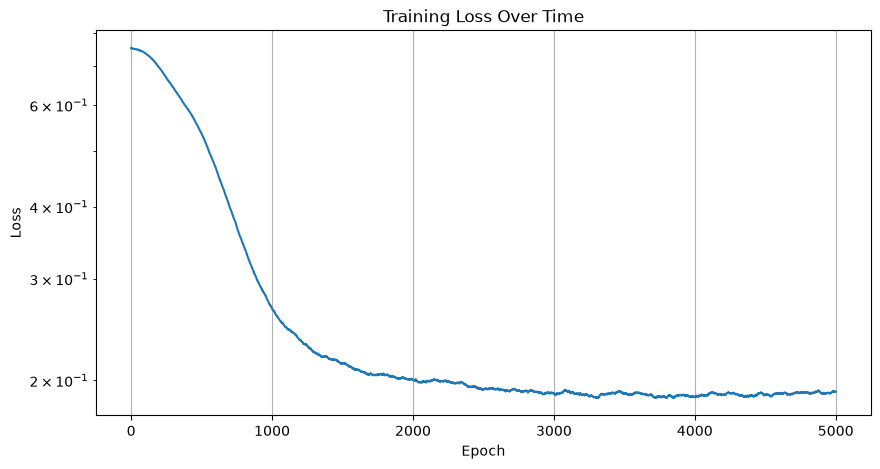

In [93]:
# Plot the training loss history with logarithmic scaling.
plt.figure(figsize=(10, 5))            # Create figure with wide aspect ratio for clarity
plt.plot(losses)                       # losses: List[float] - historical EMA loss values.
plt.title('Training Loss Over Time')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.yscale('log')                      # Use the log scale to better visualize exponential decay.
plt.grid(True)                         # Add a grid for easier value reading.
plt.show()

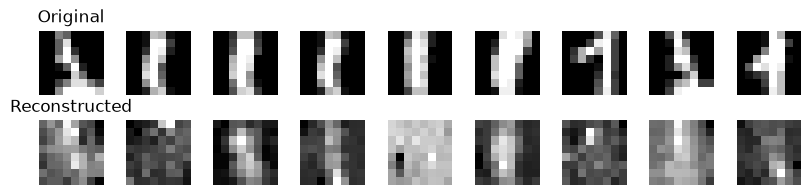

In [94]:
@partial(nnx.jit, static_argnums=(3,))
def reverse_diffusion_batch(model: UNet,
                          x: jax.Array,
                          key: jax.Array,
                          num_steps: int) -> jax.Array:
    """Efficiently generates samples from the trained diffusion model using batched reverse diffusion (with `jax.lax.scan`).

    Args:
        model (UNet): The trained U-Net model for image generation.
        x (jax.Array): Noisy image (or pure noise).
        key (jax.Array): A JAX PRNG key for generating random noise.
        num_steps (int): Number of denoising steps in the reverse diffusion process.

    Returns:
        jax.Array: The denoised image after `num_steps` iterations.
    """
    # Define the schedule for beta (noise level) and alpha (signal strength).
    beta = jnp.linspace(1e-4, 0.02, num_steps)
    alpha = 1 - beta
    alpha_cumulative = jnp.cumprod(alpha)

    def scan_step(carry: Tuple[jax.Array, jax.Array],
                 step: int) -> Tuple[Tuple[jax.Array, jax.Array], jax.Array]:
        """Applied a single denoising step."""
        # Carry-over information.
        x, key = carry

        # Create a batch of timesteps for the current iteration.
        t_batch = jnp.full((x.shape[0],), step)

        # Predict the noise using the U-Net model.
        predicted = model(x, t_batch)

        # Generate noise for the current timestep (after the first "pure noise" step).
        key, subkey = jax.random.split(key) # Split the JAX PRNG key.
        noise = jnp.where(step > 0, jax.random.normal(subkey, x.shape), 0)

        # Update the image using denoising.
        x_new = 1 / jnp.sqrt(alpha[step]) * (
            x - (1 - alpha[step]) / jnp.sqrt(1 - alpha_cumulative[step]) * predicted
        ) + jnp.sqrt(beta[step]) * noise

        # Return the updated image and carry-over information.
        return (x_new, key), x_new

    steps = jnp.arange(num_steps - 1, -1, -1)
    (final_x, _), _ = jax.lax.scan(scan_step, (x, key), steps)
    return final_x

def plot_samples(model: UNet,
                diffusion: DiffusionModel,
                images: jax.Array,
                key: jax.Array,
                num_samples: int = 9) -> None:
    """Visualize original vs reconstructed images."""
    indices = jax.random.randint(key, (num_samples,), 0, len(images))
    samples = images[indices]

    key, subkey = jax.random.split(key) # Split the JAX PRNG key.
    noisy = diffusion.forward(samples, jnp.full((num_samples,), diffusion.num_steps-1), subkey)[0]

    key, subkey = jax.random.split(key) # Split the JAX PRNG key.
    reconstructed = reverse_diffusion_batch(model, noisy, subkey, diffusion.num_steps)

    fig, axes = plt.subplots(2, num_samples, figsize=(8, 2))

    for i in range(num_samples):
        axes[0, i].imshow(samples[i, ..., 0], cmap='gray')
        axes[0, i].axis('off')
        axes[1, i].imshow(reconstructed[i, ..., 0], cmap='gray')
        axes[1, i].axis('off')

    axes[0, 0].set_title('Original')
    axes[1, 0].set_title('Reconstructed')
    plt.tight_layout()
    plt.show()

# Create a plot of original vs reconstructed images.
key, subkey = jax.random.split(key) # Split the JAX PRNG key.
plot_samples(model, diffusion, images_test, subkey)


Full forward and reverse diffusion processes:


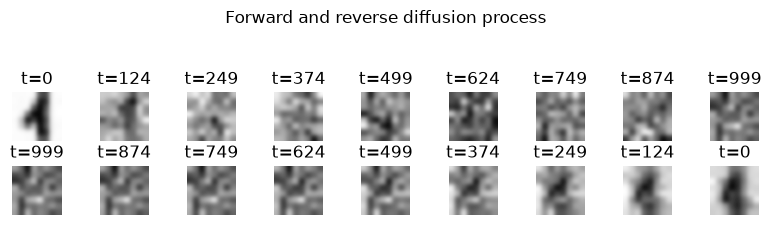

In [89]:
@partial(nnx.jit, static_argnums=(3,))
def compute_forward_sequence(model: UNet,
                           image: jax.Array,
                           key: jax.Array,
                           num_vis_steps: int) -> jax.Array:
    """Computes the forward diffusion sequence efficiently."""
    # Prepare image sequence and noise parameters.
    image_repeated = jnp.repeat(image[None], num_vis_steps, axis=0)
    timesteps = jnp.linspace(0, 999, num_vis_steps).astype(jnp.int32)  # Assuming 1000 steps
    beta = jnp.linspace(1e-4, 0.02, 1000)
    alpha = 1 - beta
    alpha_cumulative = jnp.cumprod(alpha)

    # Generate and apply noise progressively.
    noise = jax.random.normal(key, image_repeated.shape)
    noisy_images = (
        jnp.sqrt(alpha_cumulative[timesteps])[:, None, None, None] * image_repeated +
        jnp.sqrt(1 - alpha_cumulative[timesteps])[:, None, None, None] * noise
    )
    return noisy_images

@partial(nnx.jit, static_argnums=(3,))
def compute_reverse_sequence(model: UNet,
                           noisy_image: jax.Array,
                           key: jax.Array,
                           num_vis_steps: int) -> jax.Array:
    """Compute reverse diffusion sequence efficiently."""
    # Denoise completely and create interpolation sequence.
    final_image = reverse_diffusion_batch(model, noisy_image[None], key, 1000)[0]
    alphas = jnp.linspace(0, 1, num_vis_steps)
    reverse_sequence = (
        (1 - alphas)[:, None, None, None] * noisy_image +
        alphas[:, None, None, None] * final_image
    )
    return reverse_sequence

def plot_forward_and_reverse(model: UNet,
                          diffusion: DiffusionModel,
                          image: jax.Array,
                          key: jax.Array,
                          num_steps: int = 9) -> None:
    """Plot both forward and reverse diffusion processes with optimized computation."""
    # Compute the forward/reverse transformations
    key1, key2 = jax.random.split(key)
    forward_sequence = compute_forward_sequence(model, image, key1, num_steps)
    reverse_sequence = compute_reverse_sequence(model, forward_sequence[-1], key2, num_steps)

    # Plot the grid.
    fig, (ax1, ax2) = plt.subplots(2, num_steps, figsize=(8, 2))
    fig.suptitle('Forward and reverse diffusion process', y=1.1)

    timesteps = jnp.linspace(0, diffusion.num_steps-1, num_steps).astype(jnp.int32)

    # Visualize forward diffusion.
    for i in range(num_steps):
        ax1[i].imshow(forward_sequence[i, ..., 0], cmap='binary', interpolation='gaussian')
        ax1[i].axis('off')
        ax1[i].set_title(f't={timesteps[i]}')
    ax1[0].set_ylabel('Forward', rotation=90, labelpad=10)

    # Visualize reverse diffusion.
    for i in range(num_steps):
        ax2[i].imshow(reverse_sequence[i, ..., 0], cmap='binary', interpolation='gaussian')
        ax2[i].axis('off')
        ax2[i].set_title(f't={timesteps[num_steps-1-i]}')
    ax2[0].set_ylabel('Reverse', rotation=90, labelpad=10)

    plt.tight_layout()
    plt.show()

# Create a plot.
key, subkey = jax.random.split(key)
print("\nFull forward and reverse diffusion processes:")
plot_forward_and_reverse(model, diffusion, images_test[0], subkey)